In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('D:\\invoice management system\\data\\inventory.db')

In [8]:
purchase_agg_df = pd.read_sql_query("""
select 
p.PONumber,
count(distinct p.Brand) as total_brands,
sum(p.Quantity) as total_item_quantity,
sum(p.Dollars) as total_item_dollars,
avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_reveiving_delay 
from purchases p
group by p.PONumber""",conn
)

In [ ]:
pd.read_sql_query("""
select 
vi.Quantity as invoice_quantity,
vi.Dollars as invoice_dollars,
vi.Freight,

(julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
(julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay

from vendor_invoice vi

    

 """

, conn)

In [12]:
df = pd.read_sql_query("""
WITH purchase_agg AS (
    select 
        p.PONumber,
        count(distinct p.Brand) as total_brands,
        sum(p.Quantity) as total_item_quantity,
        sum(p.Dollars) as total_item_dollars,
        avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_reveiving_delay 
        from purchases p
        group by p.PONumber
)
SELECT 
    vi.PONumber,
    vi.Quantity as invoice_quantity,
    vi.Dollars as invoice_dollars,
    vi.Freight,
    (julianday(vi.InvoiceDate) - julianday(vi.PODate)) as days_po_to_invoice,
    (julianday(vi.PayDate) - julianday(vi.InvoiceDate)) as days_to_pay,
    pa.total_brands,
    pa.total_item_quantity,
    pa.total_item_dollars,
    pa.avg_reveiving_delay

FROM vendor_invoice vi
left join purchase_agg pa 
    on vi.PONumber = pa.PONumber

    """, conn)




In [13]:
df

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_reveiving_delay
0,8124,6,214.26,3.47,14.0,43.0,1,6,214.26,12.000000
1,8137,15,140.55,8.57,16.0,45.0,2,15,140.55,10.333333
2,8169,5,106.60,4.61,16.0,38.0,1,5,106.60,9.000000
3,8106,10100,137483.78,2935.20,23.0,24.0,81,10100,137483.78,12.614130
4,8170,1935,15527.25,429.20,14.0,36.0,29,1935,15527.25,8.752809
...,...,...,...,...,...,...,...,...,...,...
5538,13626,90,1563.00,8.60,16.0,35.0,2,223,6823.18,5.871795
5539,13661,4617,37300.48,186.50,18.0,39.0,110,24747,149007.56,5.050500
5540,13643,9848,202815.78,932.95,11.0,33.0,5,180,2559.72,5.000000
5541,13602,24747,149007.56,819.54,14.0,36.0,83,43240,318075.65,8.045541


In [14]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_reveiving_delay    0
dtype: int64

In [16]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_reveiving_delay    float64
dtype: object

In [17]:
def create_invoice_risk_label(row):

    #Invoice totla mismatch with item-level total
    if (abs(row['invoice_quantity'] - row['total_item_quantity']) > 5):
        return 1

    #Abnormal delay in receiving items
    if row['avg_reveiving_delay'] > 10:
        return 1


    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label, axis=1)
df['flag_invoice'].value_counts()


flag_invoice
0    3701
1    1842
Name: count, dtype: int64

<Axes: xlabel='flag_invoice'>

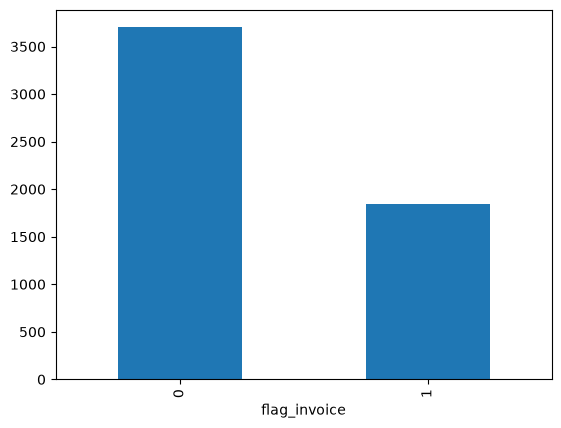

In [18]:
df['flag_invoice'].value_counts().plot(kind='bar')

In [19]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_reveiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.561438
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.034084
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.039283
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.039051
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183485
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005377
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.010526
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.034084
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.039274
avg_reveiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.313126


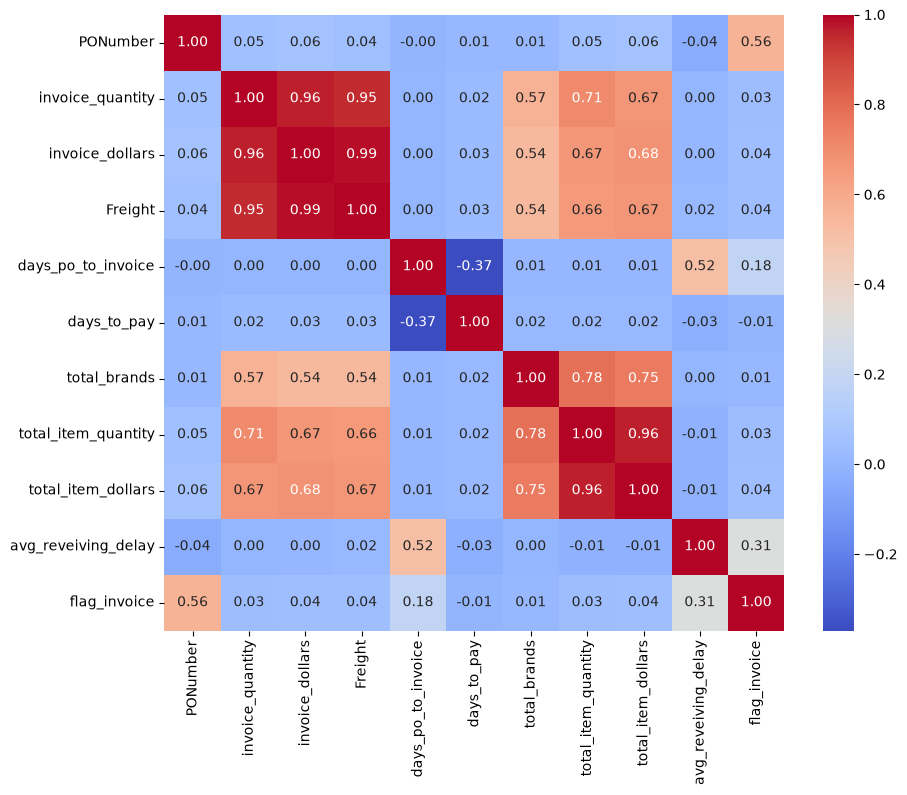

In [20]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [21]:
flagged = df[df['flag_invoice'] == 1]
normal = df[df['flag_invoice'] == 0]


In [22]:
significant_features = []
non_significant_features = []
results = []

In [23]:
metrics = ['invoice_quantity', 'invoice_dollars', 
           'Freight', 'days_po_to_invoice', 'days_to_pay', 
           'total_brands', 'total_item_quantity', 'total_item_dollars', 
           'avg_reveiving_delay']

In [30]:
from scipy.stats import ttest_ind

for metric in metrics:
    flagged_mean = flagged[metric].mean()
    normal_mean = normal[metric].mean()

    t_stat, p_value = ttest_ind(
        flagged[metric].dropna(),
        normal[metric].dropna(),
        equal_var=False
    )

    if p_value < 0.05:
        significant_features.append(metric)
        results.append({
            "metric": metric,
            "flagged_mean": round(flagged_mean, 2),
            "normal_mean": round(normal_mean, 2),
            "p_value": round(p_value, 3),
        })
    else:
        non_significant_features.append(metric)

In [31]:
non_significant_features

['days_to_pay', 'total_brands']

In [32]:
significant_features

['invoice_quantity',
 'invoice_dollars',
 'Freight',
 'days_po_to_invoice',
 'total_item_quantity',
 'total_item_dollars',
 'avg_reveiving_delay']

In [33]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6757.1),
  'normal_mean': np.float64(5711.37),
  'p_value': np.float64(0.017)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65881.35),
  'normal_mean': np.float64(54187.34),
  'p_value': np.float64(0.006)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(335.45),
  'normal_mean': np.float64(276.3),
  'p_value': np.float64(0.006)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.24),
  'normal_mean': np.float64(16.02),
  'p_value': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6757.1),
  'normal_mean': np.float64(5711.38),
  'p_value': np.float64(0.017)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65879.57),
  'normal_mean': np.float64(54188.22),
  'p_value': np.float64(0.006)},
 {'metric': 'avg_reveiving_delay',
  'flagged_mean': np.float64(8.48),
  'normal_mean': np.float64(7.27),
  'p_value': np.float64(0.0)}]

In [34]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight', 'days_po_to_invoice', 'total_brands', 'total_item_quantity', 'total_item_dollars',]]
y = df['flag_invoice']

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [43]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [45]:
model1 = LogisticRegression(random_state=42)
model1.fit(X_train_scaled, y_train)

model2 = DecisionTreeClassifier(random_state=42)
model2.fit(X_train_scaled, y_train)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [46]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

def evaluate_classifier(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)

    print(f"Model: {model_name}")
    print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
    print("\nClassification report:")
    print(classification_report(y_test, predictions, zero_division=0))
    print("Confusion matrix:")
    print(confusion_matrix(y_test, predictions))

    results = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, predictions),
        "confusion_matrix": confusion_matrix(y_test, predictions),
    }

    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X_test)[:, 1]
        results["roc_auc"] = roc_auc_score(y_test, probabilities)
        print(f"ROC-AUC: {results['roc_auc']:.4f}")

    return results

In [47]:
evaluate_classifier(model1, X_test_scaled, y_test, "Logistic Regression")
evaluate_classifier(model2, X_test_scaled, y_test, "Decision Tree")
evaluate_classifier(model3, X_test_scaled, y_test, "Random Forest")

Model: Logistic Regression
Accuracy: 0.6610

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.98      0.79       727
           1       0.57      0.06      0.11       382

    accuracy                           0.66      1109
   macro avg       0.62      0.52      0.45      1109
weighted avg       0.63      0.66      0.56      1109

Confusion matrix:
[[710  17]
 [359  23]]
ROC-AUC: 0.6161
Model: Decision Tree
Accuracy: 0.8124

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       727
           1       0.74      0.71      0.72       382

    accuracy                           0.81      1109
   macro avg       0.79      0.79      0.79      1109
weighted avg       0.81      0.81      0.81      1109

Confusion matrix:
[[631  96]
 [112 270]]
ROC-AUC: 0.7872
Model: Random Forest
Accuracy: 0.8747

Classification report:
              precision    recall  f1-sc

{'model': 'Random Forest',
 'accuracy': 0.8746618575293057,
 'confusion_matrix': array([[708,  19],
        [120, 262]]),
 'roc_auc': 0.902885702557307}

In [48]:
feature_importances = pd.DataFrame({
"feature":X_train.columns,
"importance":model3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances

,feature,importance
6,total_item_dollars,0.230704
5,total_item_quantity,0.171838
1,invoice_dollars,0.153254
2,Freight,0.141607
0,invoice_quantity,0.138017
4,total_brands,0.086308
3,days_po_to_invoice,0.078272


In [49]:
X = df[['invoice_quantity', 'invoice_dollars', 'Freight','total_item_quantity', 'total_item_dollars',]]
y = df['flag_invoice']

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model3 = RandomForestClassifier(random_state=42)
model3.fit(X_train_scaled, y_train)

evaluate_classifier(model3, X_test_scaled, y_test, "Random Forest")


Model: Random Forest
Accuracy: 0.8864

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       727
           1       0.94      0.71      0.81       382

    accuracy                           0.89      1109
   macro avg       0.90      0.85      0.87      1109
weighted avg       0.89      0.89      0.88      1109

Confusion matrix:
[[710  17]
 [109 273]]
ROC-AUC: 0.8699


{'model': 'Random Forest',
 'accuracy': 0.8863841298467088,
 'confusion_matrix': array([[710,  17],
        [109, 273]]),
 'roc_auc': 0.8699417386231879}

In [52]:
param_grid = {  
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5,6],
    "min_samples_split": [2, 5, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

In [54]:
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42,n_jobs=-1)

param_grid = {  
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 4, 5,6],
    "min_samples_split": [2, 5, 5],
    "min_samples_leaf": [1, 2, 5],
    "criterion": ["gini", "entropy"]
}

scorer = make_scorer(f1_score)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)
evaluate_classifier(grid_search.best_estimator_, X_test_scaled, y_test, "Random Forest (Tuned)")

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Model: Random Forest (Tuned)
Accuracy: 0.8927

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92       727
           1       0.96      0.72      0.82       382

    accuracy                           0.89      1109
   macro avg       0.92      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109

Confusion matrix:
[[716  11]
 [108 274]]
ROC-AUC: 0.8733


{'model': 'Random Forest (Tuned)',
 'accuracy': 0.8926961226330027,
 'confusion_matrix': array([[716,  11],
        [108, 274]]),
 'roc_auc': 0.8732562996463988}

In [55]:
from sklearn.metrics import confusion_matrix



In [56]:
confusion_matrix(grid_search.predict(X_test_scaled), y_test)

array([[716, 108],
       [ 11, 274]])

In [57]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}